# Polynomial Design and Templates

This notebook compares the higher-level builders in `qsvt.design` with the
ready-made polynomial families in `qsvt.templates`.

Goals:

- inspect bounded polynomial surrogates on $[-1,1]$
- compare template and design constructions
- study sign, inverse-like, and filter behaviour
- apply selected polynomials to a simple diagonal matrix example
- run a temporary validation block at the bottom to confirm everything looks correct

The focus is classical polynomial analysis for QSVT-style workflows:

- coefficient construction
- parity and boundedness checks
- scalar response plots
- diagonal spectral transforms

All coefficients use **ascending monomial degree order** throughout.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from qsvt.design import (
    design_filter_polynomial,
    design_inverse_polynomial,
    design_projector_polynomial,
    design_sign_polynomial,
)
from qsvt.matrices import diagonal_matrix
from qsvt.polynomials import (
    is_bounded_on_interval,
    polynomial_degree,
    polynomial_parity,
)
from qsvt.spectral import apply_function_to_hermitian
from qsvt.templates import (
    inverse_like_polynomial,
    sign_approximation_polynomial,
    soft_threshold_filter_polynomial,
)

## Helpers

Small plotting and reporting helpers used throughout the notebook.

In [2]:
def polyval(coeffs: np.ndarray, x: np.ndarray | float) -> np.ndarray:
    """Evaluate a polynomial in ascending monomial coefficient order."""
    return np.polynomial.polynomial.polyval(x, coeffs)


def summarise_polynomial(name: str, coeffs: np.ndarray) -> None:
    """Print a compact summary for a polynomial."""
    bounded = is_bounded_on_interval(
        coeffs,
        lower=-1.0,
        upper=1.0,
        bound=1.0,
        num_points=4001,
        tol=1e-8,
    )
    parity = polynomial_parity(coeffs, tol=1e-8)
    degree = polynomial_degree(coeffs)

    print(f"{name}")
    print(f"  Degree [polynomial degree]:   {degree}")
    print(f"  Parity [polynomial parity]:   {parity}")
    print(f"  Bounded [boolean]:  {bounded}")
    print(
        f"  Coeffs[:6]: {np.array2string(coeffs[:6], precision=6, suppress_small=True)}"
    )
    print()


def plot_polynomials(
    xs: np.ndarray,
    curves: list[tuple[str, np.ndarray]],
    *,
    title: str,
    xlabel: str = "x",
    ylabel: str = "P(x)",
) -> None:
    """Plot several coefficient-defined polynomials on one set of axes."""
    plt.figure(figsize=(8, 5))
    for label, coeffs in curves:
        plt.plot(xs, polyval(coeffs, xs), label=label)
    plt.axhline(0.0, linewidth=1)
    plt.axvline(0.0, linewidth=1)
    plt.xlim(xs.min(), xs.max())
    plt.ylim(-1.1, 1.1)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def max_error_on_grid(coeffs: np.ndarray, target, xs: np.ndarray) -> float:
    """Return max absolute error on a supplied grid."""
    values = polyval(coeffs, xs)
    truth = target(xs)
    return float(np.max(np.abs(values - truth)))


def rms_error_on_grid(coeffs: np.ndarray, target, xs: np.ndarray) -> float:
    """Return RMS error on a supplied grid."""
    values = polyval(coeffs, xs)
    truth = target(xs)
    return float(np.sqrt(np.mean((values - truth) ** 2)))

## Setup

We choose one compact set of parameters and compare:

- template vs design sign polynomials
- template vs design inverse-like polynomials
- template vs design filter polynomials

The design routines are more task-oriented.
The template routines are more ready-made and notebook-friendly.

In [3]:
xs = np.linspace(-1.0, 1.0, 2001)

gamma = 0.25
degree_sign = 13
degree_inverse = 13
degree_filter = 12

threshold = 0.45
mu = gamma
sharpness_sign = 8.0
sharpness_filter = 12.0

## Build sign polynomials

We compare:

- `sign_approximation_polynomial(...)` from `qsvt.templates`
- `design_sign_polynomial(...)` from `qsvt.design`

In [4]:
coeffs_sign_template = sign_approximation_polynomial(
    degree=degree_sign,
    sharpness=sharpness_sign,
)

coeffs_sign_design = design_sign_polynomial(
    gamma=gamma,
    degree=degree_sign,
)

summarise_polynomial("Sign template", coeffs_sign_template)
summarise_polynomial("Sign design", coeffs_sign_design)

Sign template
  Degree [polynomial degree]:   13
  Parity [polynomial parity]:   odd
  Bounded [boolean]:  True
  Coeffs[:6]: [  0.         6.129262   0.       -50.716      0.       251.527514]

Sign design
  Degree [polynomial degree]:   13
  Parity [polynomial parity]:   odd
  Bounded [boolean]:  True
  Coeffs[:6]: [  0.         6.457019   0.       -57.235917   0.       292.840318]



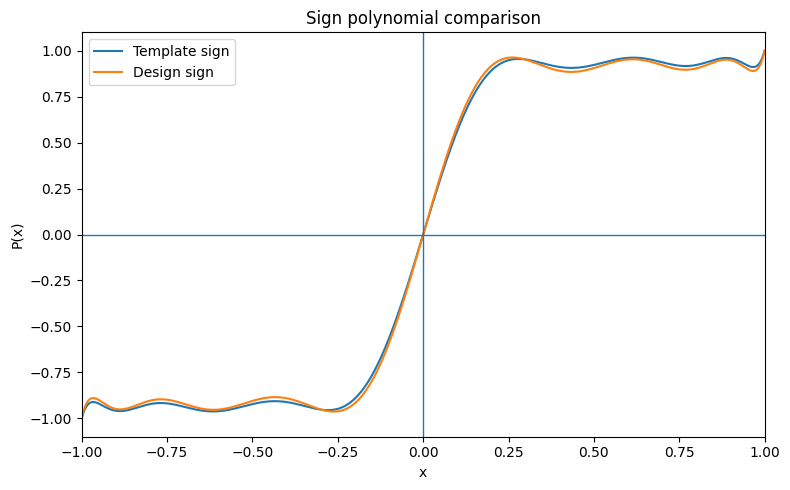

In [5]:
plot_polynomials(
    xs,
    [
        ("Template sign", coeffs_sign_template),
        ("Design sign", coeffs_sign_design),
    ],
    title="Sign polynomial comparison",
)

In [6]:
def sign_target(x):
    return np.sign(x)


mask_sign = np.abs(xs) >= gamma
xs_sign_safe = xs[mask_sign]

print("Sign approximation errors on |x| >= gamma [dimensionless x]")
print(
    "  Template max error:",
    max_error_on_grid(coeffs_sign_template, sign_target, xs_sign_safe),
)
print(
    "  Design   max error:",
    max_error_on_grid(coeffs_sign_design, sign_target, xs_sign_safe),
)
print(
    "  Template RMS error:",
    rms_error_on_grid(coeffs_sign_template, sign_target, xs_sign_safe),
)
print(
    "  Design   RMS error:",
    rms_error_on_grid(coeffs_sign_design, sign_target, xs_sign_safe),
)

Sign approximation errors on |x| >= gamma [dimensionless x]
  Template max error: 0.0934552831696136
  Design   max error: 0.1154179522161527
  Template RMS error: 0.06614683867917648
  Design   RMS error: 0.08075997225292844


## Build inverse-like polynomials

Here the comparison is slightly subtle.

- `inverse_like_polynomial(...)` is a smooth regularised inverse-like template.
- `design_inverse_polynomial(...)` is explicitly designed around the bounded
  target $\gamma/x$ away from zero.

Since QSVT-compatible polynomials must stay bounded on $[-1,1]$, we compare
both against the normalised inverse target $\gamma/x$ on
$[-1,-\gamma] \cup [\gamma,1]$.

In [7]:
coeffs_inverse_template = inverse_like_polynomial(
    degree=degree_inverse,
    mu=mu,
)

coeffs_inverse_design = design_inverse_polynomial(
    gamma=gamma,
    degree=degree_inverse,
)

summarise_polynomial("Inverse-like template", coeffs_inverse_template)
summarise_polynomial("Inverse-like design", coeffs_inverse_design)

Inverse-like template
  Degree [polynomial degree]:   13
  Parity [polynomial parity]:   odd
  Bounded [boolean]:  True
  Coeffs[:6]: [  0.         6.728973   0.       -58.268765   0.       273.617565]

Inverse-like design
  Degree [polynomial degree]:   13
  Parity [polynomial parity]:   odd
  Bounded [boolean]:  True
  Coeffs[:6]: [   0.          8.358813    0.       -104.680547    0.        576.087771]



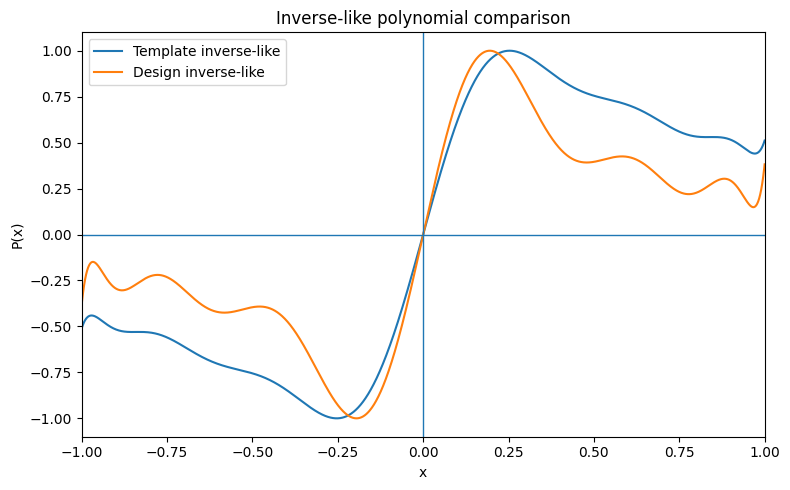

In [8]:
plot_polynomials(
    xs,
    [
        ("Template inverse-like", coeffs_inverse_template),
        ("Design inverse-like", coeffs_inverse_design),
    ],
    title="Inverse-like polynomial comparison",
)

In [9]:
def inv_target(x):
    return gamma / x


mask_inv = np.abs(xs) >= gamma
xs_inv_safe = xs[mask_inv]

print(
    "Inverse-like approximation errors against gamma/x on |x| >= gamma [dimensionless x]"
)
print(
    "  Template max error:",
    max_error_on_grid(coeffs_inverse_template, inv_target, xs_inv_safe),
)
print(
    "  Design   max error:",
    max_error_on_grid(coeffs_inverse_design, inv_target, xs_inv_safe),
)
print(
    "  Template rms error:",
    rms_error_on_grid(coeffs_inverse_template, inv_target, xs_inv_safe),
)
print(
    "  Design   rms error:",
    rms_error_on_grid(coeffs_inverse_design, inv_target, xs_inv_safe),
)

Inverse-like approximation errors against gamma/x on |x| >= gamma [dimensionless x]
  Template max error: 0.2880707591425103
  Design   max error: 0.16259666800719208
  Template rms error: 0.23148195494558868
  Design   rms error: 0.08536905981807905


## Build filter polynomials

We compare:

- `soft_threshold_filter_polynomial(...)` from `qsvt.templates`
- `design_filter_polynomial(...)` from `qsvt.design`

Both are even threshold-like bounded filters.

In [10]:
coeffs_filter_template = soft_threshold_filter_polynomial(
    degree=degree_filter,
    threshold=threshold,
    sharpness=sharpness_filter,
)

coeffs_filter_design = design_filter_polynomial(
    cutoff=threshold,
    degree=degree_filter,
    sharpness=sharpness_filter,
)

summarise_polynomial("Filter template", coeffs_filter_template)
summarise_polynomial("Filter design", coeffs_filter_design)

Filter template
  Degree [polynomial degree]:   12
  Parity [polynomial parity]:   even
  Bounded [boolean]:  True
  Coeffs[:6]: [ 0.048935  0.       -5.137833  0.       73.671274  0.      ]

Filter design
  Degree [polynomial degree]:   12
  Parity [polynomial parity]:   even
  Bounded [boolean]:  True
  Coeffs[:6]: [ 0.048935  0.       -5.137833  0.       73.671274  0.      ]



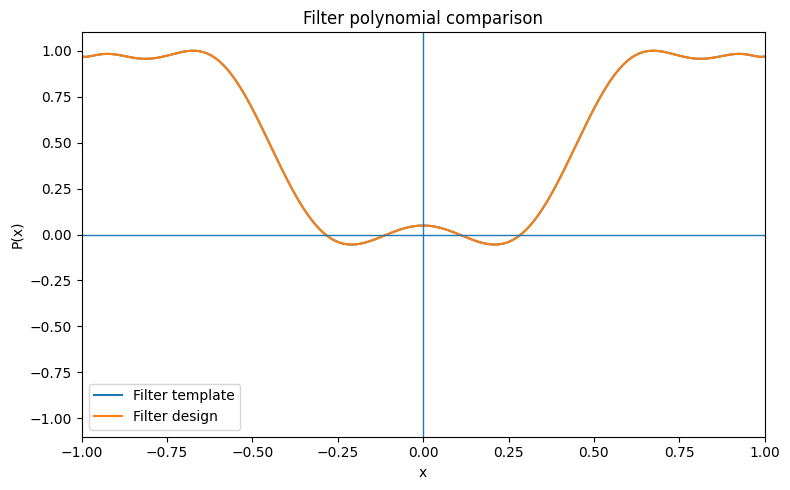

In [11]:
plot_polynomials(
    xs,
    [
        ("Filter template", coeffs_filter_template),
        ("Filter design", coeffs_filter_design),
    ],
    title="Filter polynomial comparison",
)

In [12]:
def filter_target(x):
    return 0.5 * (1.0 + np.tanh(sharpness_filter * (np.abs(x) - threshold)))


print("Filter approximation errors on [-1, 1] [dimensionless x]")
print(
    "  Template max error:",
    max_error_on_grid(coeffs_filter_template, filter_target, xs),
)
print(
    "  Design   max error:",
    max_error_on_grid(coeffs_filter_design, filter_target, xs),
)
print(
    "  Template rms error:",
    rms_error_on_grid(coeffs_filter_template, filter_target, xs),
)
print(
    "  Design   rms error:",
    rms_error_on_grid(coeffs_filter_design, filter_target, xs),
)

Filter approximation errors on [-1, 1] [dimensionless x]
  Template max error: 0.09099962265482087
  Design   max error: 0.09099962265482087
  Template rms error: 0.04297312621293089
  Design   rms error: 0.04297312621293089


## Projector polynomial from design module

This polynomial is based on the structure

$$
\frac{1 + \mathrm{sign}(x)}{2},
$$

so it should be near:

- $0$ on the negative side away from zero
- $1$ on the positive side away from zero

In [13]:
coeffs_projector = design_projector_polynomial(
    gamma=gamma,
    degree=degree_sign,
)

summarise_polynomial("Projector design", coeffs_projector)

Projector design
  Degree [polynomial degree]:   13
  Parity [polynomial parity]:   mixed
  Bounded [boolean]:  True
  Coeffs[:6]: [  0.5        3.228509   0.       -28.617959   0.       146.420159]



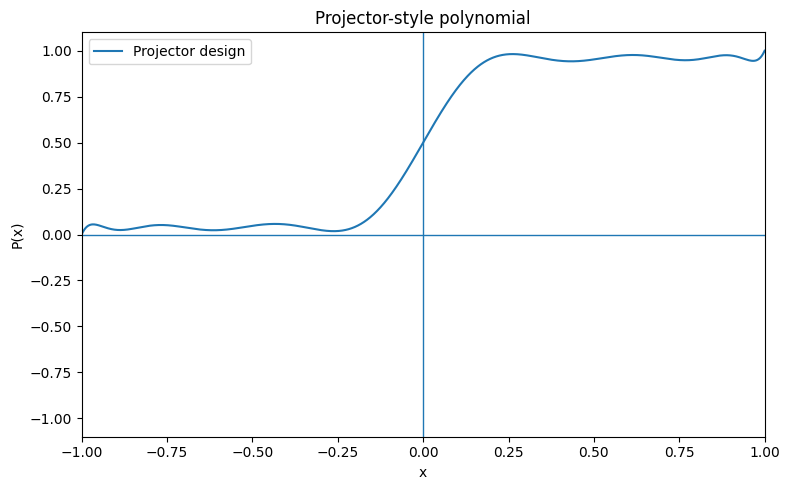

In [14]:
plot_polynomials(
    xs,
    [("Projector design", coeffs_projector)],
    title="Projector-style polynomial",
)

In [15]:
def projector_target(x):
    return 0.5 * (1.0 + np.sign(x))


mask_projector = np.abs(xs) >= gamma
xs_projector_safe = xs[mask_projector]

print("Projector approximation errors on |x| >= gamma [dimensionless x]")
print(
    "  Max error:",
    max_error_on_grid(coeffs_projector, projector_target, xs_projector_safe),
)
print(
    "  RMS error:",
    rms_error_on_grid(coeffs_projector, projector_target, xs_projector_safe),
)

Projector approximation errors on |x| >= gamma [dimensionless x]
  Max error: 0.05770897610807635
  RMS error: 0.04037998612646422


## Diagonal matrix example

A diagonal Hermitian matrix is the cleanest setting for checking that the
scalar polynomial behaviour matches the corresponding matrix-function action.

We build a small diagonal matrix and apply selected polynomials spectrally.

In [16]:
diag_entries = np.array(
    [-0.90, -0.55, -0.30, -0.10, 0.10, 0.30, 0.55, 0.90], dtype=float
)
A = diagonal_matrix(diag_entries)

print(f"A = {A}")

A = [[-0.9   0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.   -0.55  0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.   -0.3   0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.   -0.1   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.1   0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.3   0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.55  0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.9 ]]


In [17]:
def apply_polynomial_to_diagonal(diag: np.ndarray, coeffs: np.ndarray) -> np.ndarray:
    """Apply a polynomial to diagonal entries directly."""
    return polyval(coeffs, diag)


diag_sign_design = apply_polynomial_to_diagonal(diag_entries, coeffs_sign_design)
diag_inverse_design = apply_polynomial_to_diagonal(diag_entries, coeffs_inverse_design)
diag_filter_design = apply_polynomial_to_diagonal(diag_entries, coeffs_filter_design)
diag_projector_design = apply_polynomial_to_diagonal(diag_entries, coeffs_projector)

print("Diag entries:")
print(diag_entries)
print()
print("Design sign on diag:")
print(np.round(diag_sign_design, 6))
print()
print("Design inverse-like on diag:")
print(np.round(diag_inverse_design, 6))
print()
print("Design filter on diag:")
print(np.round(diag_filter_design, 6))
print()
print("Design projector on diag:")
print(np.round(diag_projector_design, 6))

Diag entries:
[-0.9  -0.55 -0.3  -0.1   0.1   0.3   0.55  0.9 ]

Design sign on diag:
[-0.9488   -0.9341   -0.951784 -0.591317  0.591317  0.951784  0.9341
  0.9488  ]

Design inverse-like on diag:
[-0.293721 -0.41768  -0.774708 -0.736804  0.736804  0.774708  0.41768
  0.293721]

Design filter on diag:
[0.979311 0.841569 0.023234 0.004676 0.004676 0.023234 0.841569 0.979311]

Design projector on diag:
[0.0256   0.03295  0.024108 0.204342 0.795658 0.975892 0.96705  0.9744  ]


We can also compare direct diagonal evaluation with the package spectral
helper `apply_function_to_hermitian` using polynomial evaluation as the scalar
function.

In [18]:
A_sign_from_spectral = apply_function_to_hermitian(
    A,
    lambda x: polyval(coeffs_sign_design, x),
)

A_filter_from_spectral = apply_function_to_hermitian(
    A,
    lambda x: polyval(coeffs_filter_design, x),
)

A_projector_from_spectral = apply_function_to_hermitian(
    A,
    lambda x: polyval(coeffs_projector, x),
)

print("Diag(sign_design(A)) via spectral helper:")
print(np.round(np.diag(A_sign_from_spectral), 6))
print()
print("Diag(filter_design(A)) via spectral helper:")
print(np.round(np.diag(A_filter_from_spectral), 6))
print()
print("Diag(projector_design(A)) via spectral helper:")
print(np.round(np.diag(A_projector_from_spectral), 6))

Diag(sign_design(A)) via spectral helper:
[-0.9488   -0.9341   -0.951784 -0.591317  0.591317  0.951784  0.9341
  0.9488  ]

Diag(filter_design(A)) via spectral helper:
[0.979311 0.841569 0.023234 0.004676 0.004676 0.023234 0.841569 0.979311]

Diag(projector_design(A)) via spectral helper:
[0.0256   0.03295  0.024108 0.204342 0.795658 0.975892 0.96705  0.9744  ]


## Visual comparison on the diagonal spectrum

This makes the spectral action easier to inspect at the sample eigenvalues.

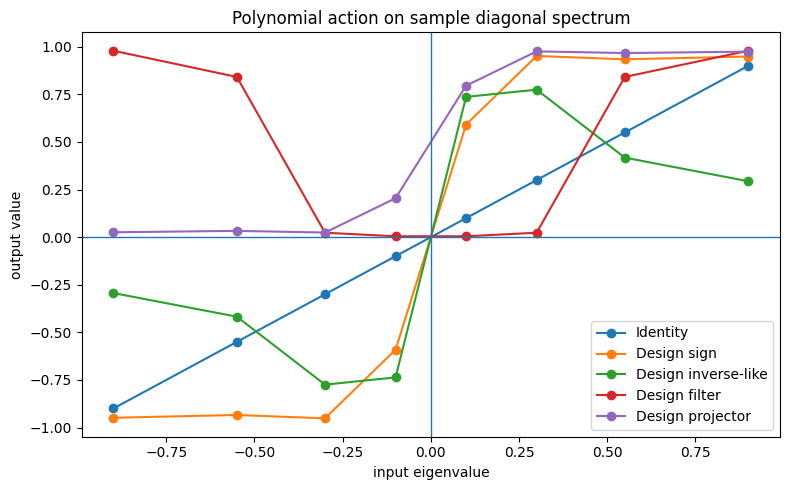

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(diag_entries, diag_entries, "o-", label="Identity")
plt.plot(diag_entries, diag_sign_design, "o-", label="Design sign")
plt.plot(diag_entries, diag_inverse_design, "o-", label="Design inverse-like")
plt.plot(diag_entries, diag_filter_design, "o-", label="Design filter")
plt.plot(diag_entries, diag_projector_design, "o-", label="Design projector")
plt.axhline(0.0, linewidth=1)
plt.axvline(0.0, linewidth=1)
plt.xlabel("input eigenvalue")
plt.ylabel("output value")
plt.title("Polynomial action on sample diagonal spectrum")
plt.legend()
plt.tight_layout()
plt.show()

## Validation block

In [20]:
validation_items = [
    ("Sign template", coeffs_sign_template),
    ("Sign design", coeffs_sign_design),
    ("Inverse template", coeffs_inverse_template),
    ("Inverse design", coeffs_inverse_design),
    ("Filter template", coeffs_filter_template),
    ("Filter design", coeffs_filter_design),
    ("Projector design", coeffs_projector),
]

for name, coeffs in validation_items:
    print(name)
    print("  Degree [polynomial degree]:", polynomial_degree(coeffs))
    print("  Parity [polynomial parity]:", polynomial_parity(coeffs, tol=1e-8))
    print(
        "  bounded [boolean]:",
        is_bounded_on_interval(
            coeffs,
            lower=-1.0,
            upper=1.0,
            bound=1.0,
            num_points=4001,
            tol=1e-8,
        ),
    )
    print("  max_abs_on_grid:", float(np.max(np.abs(polyval(coeffs, xs)))))
    print()

print("--- safe-region scalar checks ---")
print(
    "Sign template max err on |x| >= gamma [dimensionless x]:",
    max_error_on_grid(coeffs_sign_template, sign_target, xs_sign_safe),
)
print(
    "Sign design   max err on |x| >= gamma [dimensionless x]:",
    max_error_on_grid(coeffs_sign_design, sign_target, xs_sign_safe),
)
print(
    "Inverse template max err vs gamma/x on |x| >= gamma [dimensionless x]:",
    max_error_on_grid(coeffs_inverse_template, inv_target, xs_inv_safe),
)
print(
    "Inverse design   max err vs gamma/x on |x| >= gamma [dimensionless x]:",
    max_error_on_grid(coeffs_inverse_design, inv_target, xs_inv_safe),
)
print(
    "Filter template max err on [-1,1]:",
    max_error_on_grid(coeffs_filter_template, filter_target, xs),
)
print(
    "Filter design   max err on [-1,1]:",
    max_error_on_grid(coeffs_filter_design, filter_target, xs),
)
print(
    "Projector design max err on |x| >= gamma [dimensionless x]:",
    max_error_on_grid(coeffs_projector, projector_target, xs_projector_safe),
)
print()

print("--- projector checkpoints ---")
for x0 in (-0.8, -0.5, -gamma, gamma, 0.5, 0.8):
    print(f"x={x0:+.2f} -> value {polyval(coeffs_projector, x0): .6f}")
print()

print("--- Diagonal outputs ---")
print("Diag entries:")
print(np.round(diag_entries, 6))
print("Design sign:")
print(np.round(diag_sign_design, 6))
print("Design inverse-like:")
print(np.round(diag_inverse_design, 6))
print("Design filter:")
print(np.round(diag_filter_design, 6))
print("Design projector:")
print(np.round(diag_projector_design, 6))
print()

print("--- Spectral consistency checks ---")
print(
    "Sign diag consistency [boolean]:",
    bool(np.allclose(np.diag(A_sign_from_spectral), diag_sign_design, atol=1e-8)),
)
print(
    "Filter diag consistency [boolean]:",
    bool(np.allclose(np.diag(A_filter_from_spectral), diag_filter_design, atol=1e-8)),
)
print(
    "Projector diag consistency [boolean]:",
    bool(
        np.allclose(
            np.diag(A_projector_from_spectral), diag_projector_design, atol=1e-8
        )
    ),
)

Sign template
  Degree [polynomial degree]: 13
  Parity [polynomial parity]: odd
  bounded [boolean]: True
  max_abs_on_grid: 0.9999999999999876

Sign design
  Degree [polynomial degree]: 13
  Parity [polynomial parity]: odd
  bounded [boolean]: True
  max_abs_on_grid: 0.9999999999999538

Inverse template
  Degree [polynomial degree]: 13
  Parity [polynomial parity]: odd
  bounded [boolean]: True
  max_abs_on_grid: 1.0

Inverse design
  Degree [polynomial degree]: 13
  Parity [polynomial parity]: odd
  bounded [boolean]: True
  max_abs_on_grid: 1.0

Filter template
  Degree [polynomial degree]: 12
  Parity [polynomial parity]: even
  bounded [boolean]: True
  max_abs_on_grid: 0.9999996169147369

Filter design
  Degree [polynomial degree]: 12
  Parity [polynomial parity]: even
  bounded [boolean]: True
  max_abs_on_grid: 0.9999996169147369

Projector design
  Degree [polynomial degree]: 13
  Parity [polynomial parity]: mixed
  bounded [boolean]: True
  max_abs_on_grid: 0.999999999999976

## Validation

Compact checks for the expected tutorial behavior.


In [21]:
assert all(
    is_bounded_on_interval(
        coeffs, lower=-1.0, upper=1.0, bound=1.0, num_points=4001, tol=1e-8
    )
    for _, coeffs in validation_items
)
assert max_error_on_grid(coeffs_sign_design, np.sign, xs_sign_safe) < 0.2
assert max_error_on_grid(coeffs_inverse_design, lambda x: gamma / x, xs_inv_safe) < 0.2
assert max_error_on_grid(coeffs_projector, projector_target, xs_projector_safe) < 0.08
assert np.allclose(np.diag(A_sign_from_spectral), diag_sign_design)
assert np.allclose(np.diag(A_filter_from_spectral), diag_filter_design)
assert np.allclose(np.diag(A_projector_from_spectral), diag_projector_design)

print(
    f"Sign_design_max_error: {max_error_on_grid(coeffs_sign_design, np.sign, xs_sign_safe):.3e}"
)
print(
    f"Inverse_design_max_error: {max_error_on_grid(coeffs_inverse_design, lambda x: gamma / x, xs_inv_safe):.3e}"
)
print(
    f"Projector_design_max_error: {max_error_on_grid(coeffs_projector, projector_target, xs_projector_safe):.3e}"
)
print("validation: passed")

Sign_design_max_error: 1.154e-01
Inverse_design_max_error: 1.626e-01
Projector_design_max_error: 5.771e-02
validation: passed
